
3. Plotting data directly with pandas


This section uses the pandas pd.plot() method on a DataFrame to plot columns directly.

https://datatofish.com/plot-dataframe-pandas/

https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html

line

scatter

bar

hist

df.plot(subplots=True, figsize=(6, 6))

To plot data with pandas, we first have to import it as pd.

In [1]:
import pandas as pd

Now we need some data to check out

In [2]:
# Let's import the car_sales datadet
car_sales = pd.read_csv("car-sales (1).csv")

In [3]:
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"
5,Toyota,Green,99213,4,"$4,500.00"
6,Honda,Blue,45698,4,"$7,500.00"
7,Honda,Blue,54738,4,"$7,000.00"
8,Toyota,White,60000,4,"$6,250.00"
9,Nissan,White,31600,4,"$9,700.00"



## Line
# Concept
# DataFrame

Often, reading things won't make sense. Practice writing code for yourself, get it out of the docs and into your workspace. See what happens when you run it.

Let's start with trying to replicate the pandas visualization documents.

In [6]:
import numpy as np

In [7]:

# Start with some dummy data
ts = pd.Series(np.random.randn(1000),
               index=pd.date_range('1/1/2020', periods=1000))
ts

2020-01-01    2.057819
2020-01-02   -0.865127
2020-01-03    0.078156
2020-01-04   -1.561473
2020-01-05    0.935336
                ...   
2022-09-22   -2.370297
2022-09-23    0.474299
2022-09-24   -0.279836
2022-09-25    1.533816
2022-09-26   -1.497276
Freq: D, Length: 1000, dtype: float64

In [8]:

# What does cumsum() do?
ts.cumsum()

2020-01-01    2.057819
2020-01-02    1.192692
2020-01-03    1.270848
2020-01-04   -0.290625
2020-01-05    0.644711
                ...   
2022-09-22    3.735148
2022-09-23    4.209448
2022-09-24    3.929611
2022-09-25    5.463427
2022-09-26    3.966152
Freq: D, Length: 1000, dtype: float64

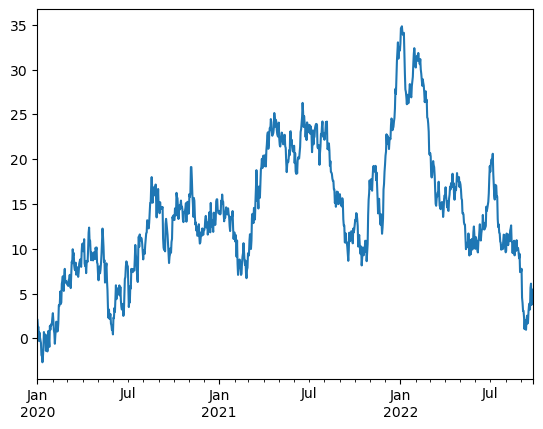

In [9]:
ts.cumsum().plot();


## Working with actual data
Let's do a little data manipulation on our car_sales DataFrame.

In [11]:
# Remove price column symbols
car_sales["Price"] = car_sales["Price"].str.replace(r'[\$,.]', '', regex=True)
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,400000
1,Honda,Red,87899,4,500000
2,Toyota,Blue,32549,3,700000
3,BMW,Black,11179,5,2200000
4,Nissan,White,213095,4,350000
5,Toyota,Green,99213,4,450000
6,Honda,Blue,45698,4,750000
7,Honda,Blue,54738,4,700000
8,Toyota,White,60000,4,625000
9,Nissan,White,31600,4,970000


In [12]:
# Removes last two zeroes
car_sales["Price"] = car_sales["Price"].str[:-2]
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,4000
1,Honda,Red,87899,4,5000
2,Toyota,Blue,32549,3,7000
3,BMW,Black,11179,5,22000
4,Nissan,White,213095,4,3500
5,Toyota,Green,99213,4,4500
6,Honda,Blue,45698,4,7500
7,Honda,Blue,54738,4,7000
8,Toyota,White,60000,4,6250
9,Nissan,White,31600,4,9700


In [13]:
# Add a date column
car_sales["Sale Date"] = pd.date_range("1/1/2020", periods=len(car_sales))
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date
0,Toyota,White,150043,4,4000,2020-01-01
1,Honda,Red,87899,4,5000,2020-01-02
2,Toyota,Blue,32549,3,7000,2020-01-03
3,BMW,Black,11179,5,22000,2020-01-04
4,Nissan,White,213095,4,3500,2020-01-05
5,Toyota,Green,99213,4,4500,2020-01-06
6,Honda,Blue,45698,4,7500,2020-01-07
7,Honda,Blue,54738,4,7000,2020-01-08
8,Toyota,White,60000,4,6250,2020-01-09
9,Nissan,White,31600,4,9700,2020-01-10


In [14]:
# Make total sales column (doesn't work, adds as string)
#car_sales["Total Sales"] = car_sales["Price"].cumsum()

# Oops... want them as int's not string
car_sales["Total Sales"] = car_sales["Price"].astype(int).cumsum()
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date,Total Sales
0,Toyota,White,150043,4,4000,2020-01-01,4000
1,Honda,Red,87899,4,5000,2020-01-02,9000
2,Toyota,Blue,32549,3,7000,2020-01-03,16000
3,BMW,Black,11179,5,22000,2020-01-04,38000
4,Nissan,White,213095,4,3500,2020-01-05,41500
5,Toyota,Green,99213,4,4500,2020-01-06,46000
6,Honda,Blue,45698,4,7500,2020-01-07,53500
7,Honda,Blue,54738,4,7000,2020-01-08,60500
8,Toyota,White,60000,4,6250,2020-01-09,66750
9,Nissan,White,31600,4,9700,2020-01-10,76450


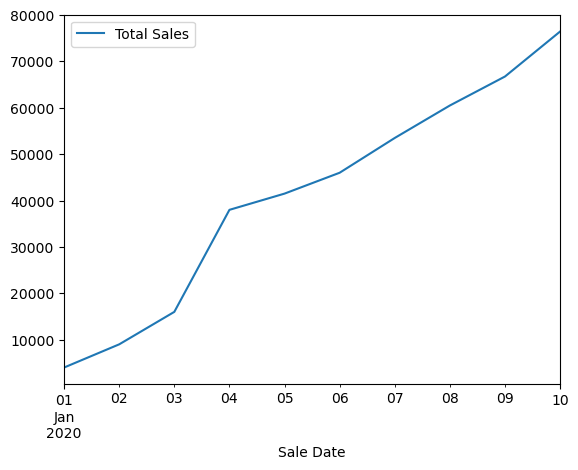

In [15]:

car_sales.plot(x='Sale Date', y='Total Sales');


# Scatter
## Concept
## DataFrame

<Axes: xlabel='Odometer (KM)', ylabel='Price'>

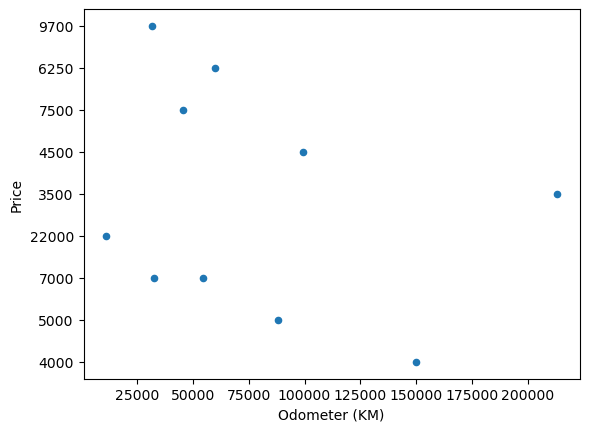

In [16]:

car_sales.plot(x="Odometer (KM)", y="Price", kind="scatter")

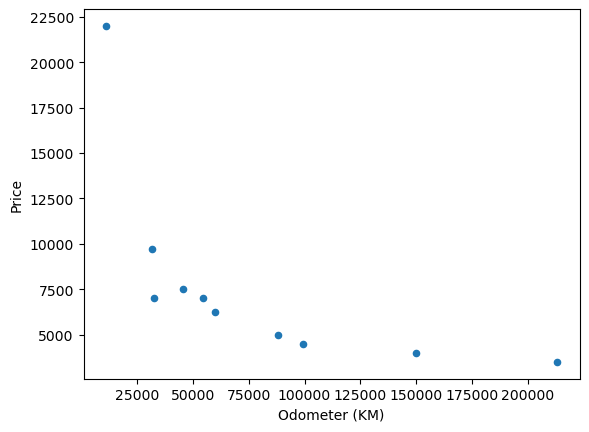

In [17]:

# Convert Price to int
car_sales["Price"] = car_sales["Price"].astype(int)
car_sales.plot(x="Odometer (KM)", y="Price", kind='scatter');


# Bar
Concept

DataFrame

In [19]:
x = np.random.rand(10, 4)
x

array([[0.16189281, 0.85091749, 0.12852356, 0.59373118],
       [0.34665519, 0.43105361, 0.20123143, 0.38670772],
       [0.55369715, 0.24344133, 0.48809128, 0.93285514],
       [0.53082558, 0.05706125, 0.82475084, 0.96453171],
       [0.59447531, 0.65678691, 0.35837843, 0.17928897],
       [0.54859326, 0.44075362, 0.30715748, 0.47526198],
       [0.7062056 , 0.82301276, 0.67703563, 0.85546889],
       [0.68755191, 0.17943979, 0.41403228, 0.86193446],
       [0.28289107, 0.97729625, 0.93211541, 0.96794307],
       [0.36698629, 0.49898592, 0.63290881, 0.77535362]])

In [23]:

df = pd.DataFrame(x, columns=['a', 'b', 'c', 'd'])
df

,a,b,c,d
0,0.161893,0.850917,0.128524,0.593731
1,0.346655,0.431054,0.201231,0.386708
2,0.553697,0.243441,0.488091,0.932855
3,0.530826,0.057061,0.824751,0.964532
4,0.594475,0.656787,0.358378,0.179289
5,0.548593,0.440754,0.307157,0.475262
6,0.706206,0.823013,0.677036,0.855469
7,0.687552,0.179440,0.414032,0.861934
8,0.282891,0.977296,0.932115,0.967943
9,0.366986,0.498986,0.632909,0.775354


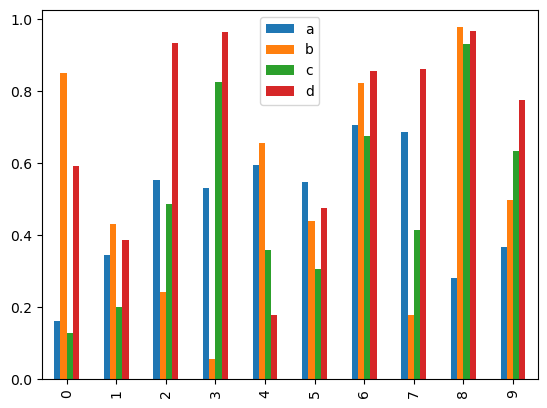

In [26]:
df.plot.bar();

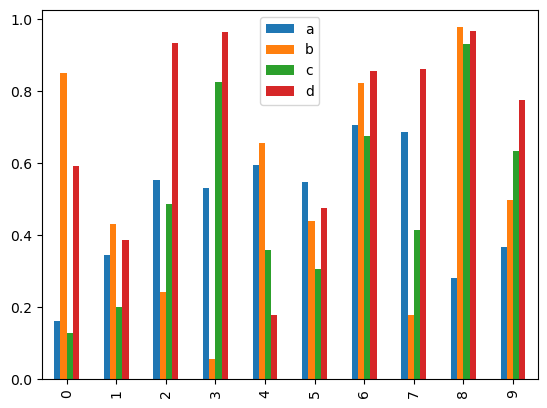

In [27]:

# Can do the same thing with 'kind' keyword
df.plot(kind='bar');

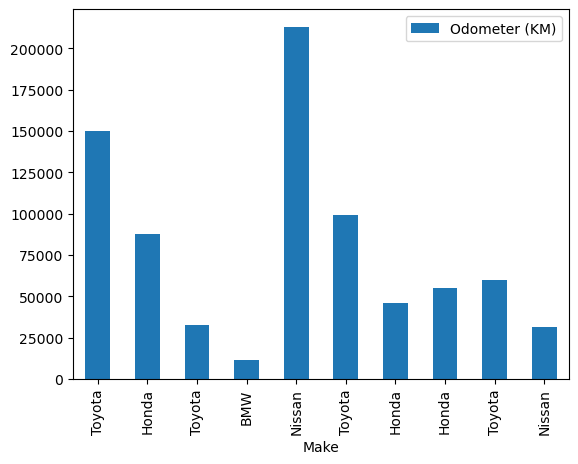

In [29]:
car_sales.plot(x = 'Make', y = 'Odometer (KM)', kind = 'bar');

# Histograms

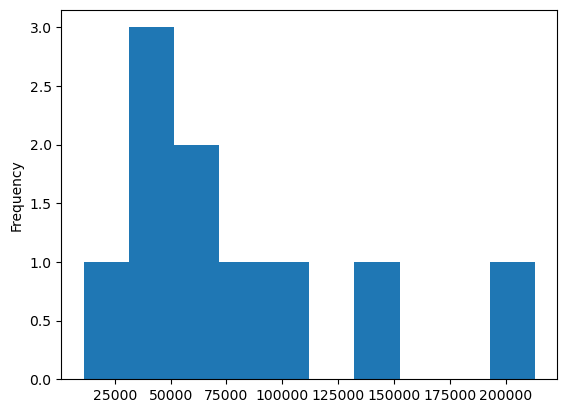

In [30]:
car_sales["Odometer (KM)"].plot.hist();

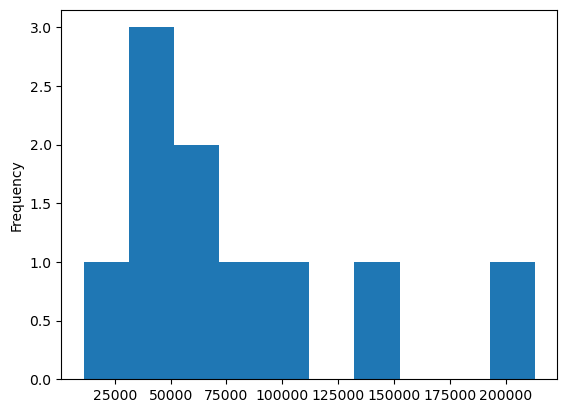

In [32]:
car_sales["Odometer (KM)"].plot(kind = 'hist');

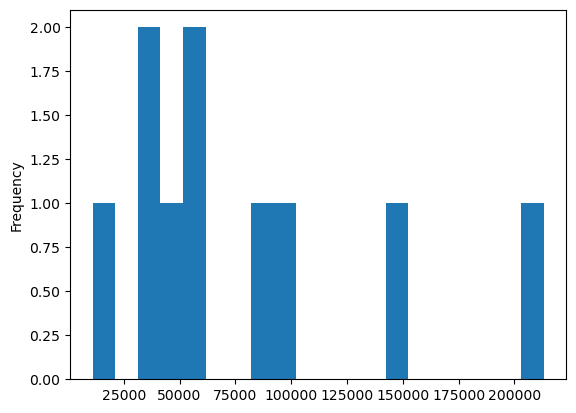

In [33]:

# Default number of bins is 10 
car_sales["Odometer (KM)"].plot.hist(bins=20);

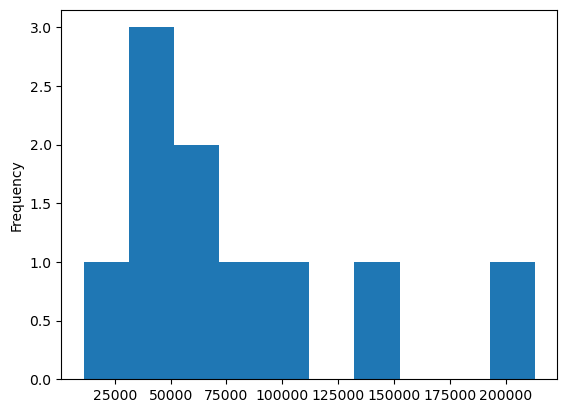

In [34]:
car_sales["Odometer (KM)"].plot.hist(bins = 10);